![](img/cover.png)

# What the Data Gets Wrong About Gun Violence in Philadelphia

### When people talk about gun violence in Philadelphia, the conversation usually centers around where it’s “worst.” Certain areas get labeled as the most dangerous, and the story often stops there.

### But that story depends entirely on how we choose to look at the data.

### This analysis uses the OpenDataPhilly PPD shootings dataset to explore how small shifts in perspective — looking at proportions instead of totals, or patterns over time instead of static counts — can completely change what the data seems to say.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('openphilly_data_shootings.csv')
df.head()

,the_geom,the_geom_webmercator,objectid,year,dc_key,code,date_,time,race,sex,...,location,latino,point_x,point_y,dist,inside,outside,fatal,lat,lng
0,0101000020E6100000E0E9426A62C552C0829DCD702401...,0101000020110F00004AF93FD46DE25FC1DA66A2D02991...,10517503,2023,2.023150e+11,111.0,2023-01-18 00:00:00+00,08:21:00,W,M,...,4300 BLOCK JOSEPHINE ST,1.0,-75.084132,40.008925,15.0,1.0,0.0,1.0,40.008925,-75.084132
1,0101000020E6100000C6E7463FF7C252C06882B8DD1103...,0101000020110F0000ECC12F1C52DE5FC191B0CAFF4C93...,10517504,2023,2.023150e+11,411.0,2023-01-18 00:00:00+00,13:03:00,B,M,...,4700 BLOCK UNRUH AVE,0.0,-75.046341,40.023983,15.0,0.0,1.0,0.0,40.023983,-75.046341
2,0101000020E610000060A671987DC452C02B070652DA01...,0101000020110F000082B0EE27E9E05FC1CE751B7FF391...,10517505,2023,2.023150e+11,111.0,2023-01-19 00:00:00+00,18:02:00,B,M,...,2000 BLOCK SCATTERGOOD ST,0.0,-75.070166,40.014475,15.0,0.0,1.0,0.0,40.014475,-75.070166
3,0101000020E610000060A671987DC452C02B070652DA01...,0101000020110F000082B0EE27E9E05FC1CE751B7FF391...,10517506,2023,2.023150e+11,111.0,2023-01-19 00:00:00+00,18:02:00,B,M,...,2000 BLOCK SCATTERGOOD ST,0.0,-75.070166,40.014475,15.0,0.0,1.0,0.0,40.014475,-75.070166
4,0101000020E610000060A671987DC452C02B070652DA01...,0101000020110F000082B0EE27E9E05FC1CE751B7FF391...,10517507,2023,2.023150e+11,111.0,2023-01-19 00:00:00+00,18:02:00,B,M,...,2000 BLOCK SCATTERGOOD ST,0.0,-75.070166,40.014475,15.0,0.0,1.0,0.0,40.014475,-75.070166


#### This dataset records reported shootings in Philadelphia and includes information like date, time, police district, age, race, sex, and whether the incident was fatal.

#### Rather than walking step by step through the mechanics of the analysis, I want to use the data to tell a story. And the first version of that story is a familiar one.

In [29]:
df.columns.tolist()

['the_geom',
 'the_geom_webmercator',
 'objectid',
 'year',
 'dc_key',
 'code',
 'date_',
 'time',
 'race',
 'sex',
 'age',
 'wound',
 'officer_involved',
 'offender_injured',
 'offender_deceased',
 'location',
 'latino',
 'point_x',
 'point_y',
 'dist',
 'inside',
 'outside',
 'fatal',
 'lat',
 'lng']

## The First Story: Some Districts Clearly Stand Out

#### At first glance, the data seems to tell a very straightforward story. Some police districts report far more shootings than others. If we count incidents by district, the gaps are immediately visible.

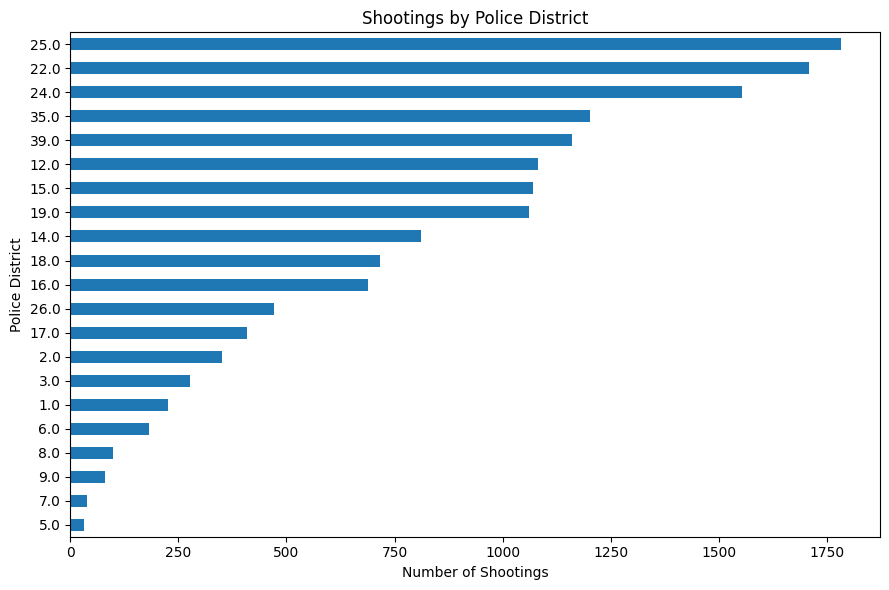

In [30]:
district_counts = df['dist'].value_counts().sort_values()

plt.figure(figsize=(9, 6))
district_counts.plot(kind='barh')
plt.title('Shootings by Police District')
plt.xlabel('Number of Shootings')
plt.ylabel('Police District')
plt.tight_layout()
plt.show()

### This is the kind of chart that encourages a quick conclusion. A few districts appear to dominate, and it becomes tempting to reduce the story of gun violence in Philadelphia to a ranking.

#### But this is also exactly where things get a little slippery.

##### Raw counts are useful, but they can flatten the story. They show volume, but not always distribution in a way that helps us think more carefully.

## The Twist: Totals Are Not the Whole Story

### To push the question a little further, I looked at each district’s share of total shootings instead of just the raw count.

#### This may sound like a small shift, but it changes the way the problem looks.

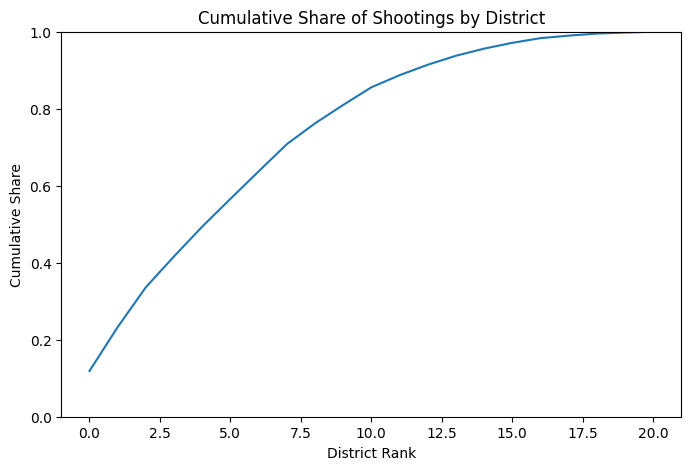

In [33]:
district_sorted = df['dist'].value_counts(normalize=True).sort_values(ascending=False)

cumulative = district_sorted.cumsum()

plt.figure(figsize=(8,5))
cumulative.reset_index(drop=True).plot()
plt.title('Cumulative Share of Shootings by District')
plt.xlabel('District Rank')
plt.ylabel('Cumulative Share')
plt.ylim(0,1)
plt.show()

### Looking at the cumulative distribution makes the pattern even clearer. The curve rises quickly at first, showing that a relatively small number of districts account for a large share of shootings.

After that, the line begins to flatten, meaning that the remaining districts still contribute—but more gradually.

This reinforces an important point: gun violence in Philadelphia is concentrated, but not isolated. A few areas carry a disproportionate share, yet the issue remains spread across the city as a whole.

In other words, there isn’t a single “worst” place—there’s a pattern of concentration layered onto a broader, citywide problem.

### At first glance, switching from raw counts to proportions doesn’t seem to change much—the same districts still appear at the top.

But this is also where interpretation gets tricky.

These proportions show each district’s share of total shootings—not how dangerous a district is relative to its size or population. A district with a larger share may simply have more incidents overall, not necessarily a higher rate of violence per resident.

In that sense, the chart is both useful and limited. It helps us understand how shootings are distributed across the city, but it doesn’t fully explain risk.

This is a reminder that even when data is technically correct, it can still be easy to misinterpret without the right context.

## Violence Over Time: Less Random Than It Seems

It is easy to think of shootings as isolated incidents that happen unpredictably. But time adds another dimension to the story.

When I grouped the data by month, the pattern became much less random than I expected.

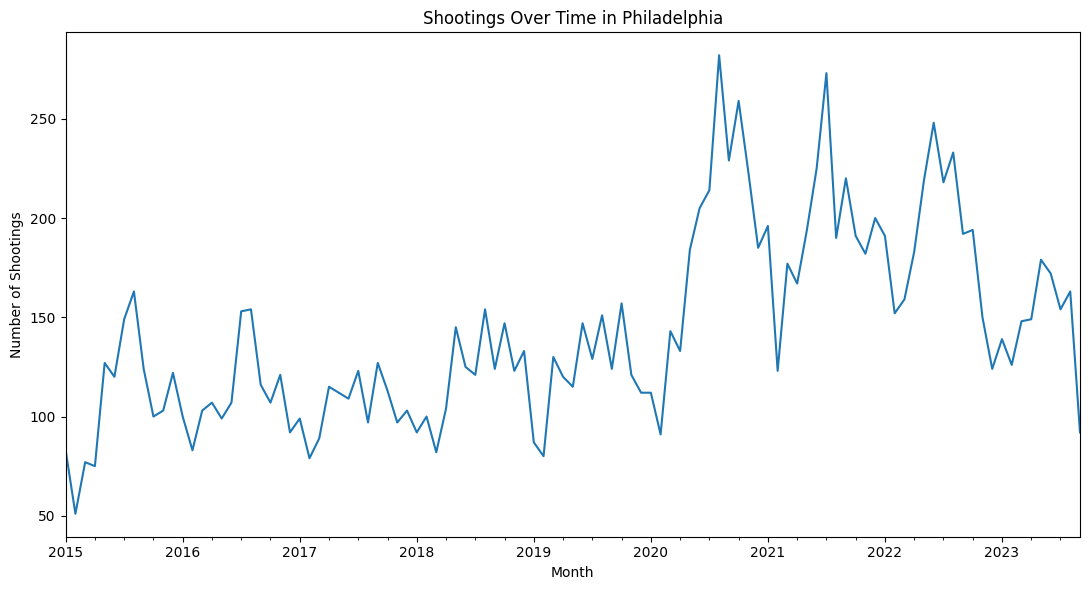

In [7]:
df['date_'] = pd.to_datetime(df['date_'])
monthly_shootings = df.set_index('date_').resample('ME').size()

plt.figure(figsize=(11, 6))
monthly_shootings.plot()
plt.title('Shootings Over Time in Philadelphia')
plt.xlabel('Month')
plt.ylabel('Number of Shootings')
plt.tight_layout()
plt.show()

Rather than randomness, we see fluctuation. Some periods spike, others dip.

Even without explaining why, this already changes the story. Violence is not evenly spread across time—it has a rhythm.

### So far, the story has focused on *where* shootings happen.

But location is only one part of the picture.

To understand whether these incidents are actually random or patterned, we also need to look at *when* they occur.

## A Closer Look: Time of Day

If shootings were completely random, we would expect them to be spread fairly evenly throughout the day.

But when I broke the data down by hour, a very different pattern showed up.

Instead of randomness, shootings clearly cluster at specific times. The early morning hours are relatively low, but incidents steadily increase throughout the day, peaking in the late evening and nighttime.

This shift is striking. What initially feels like a series of isolated, unpredictable events actually follows a consistent daily rhythm.

In other words, the timing of violence isn’t random—it’s structured. And once we look for that structure, it becomes impossible to ignore.

This also raises a bigger question: if violence follows patterns this clearly, what factors might be driving them?

In [26]:
df['datetime'] = pd.to_datetime(
    df['date_'].astype(str) + ' ' + df['time'].astype(str),
    format='mixed',
    errors='coerce'
)


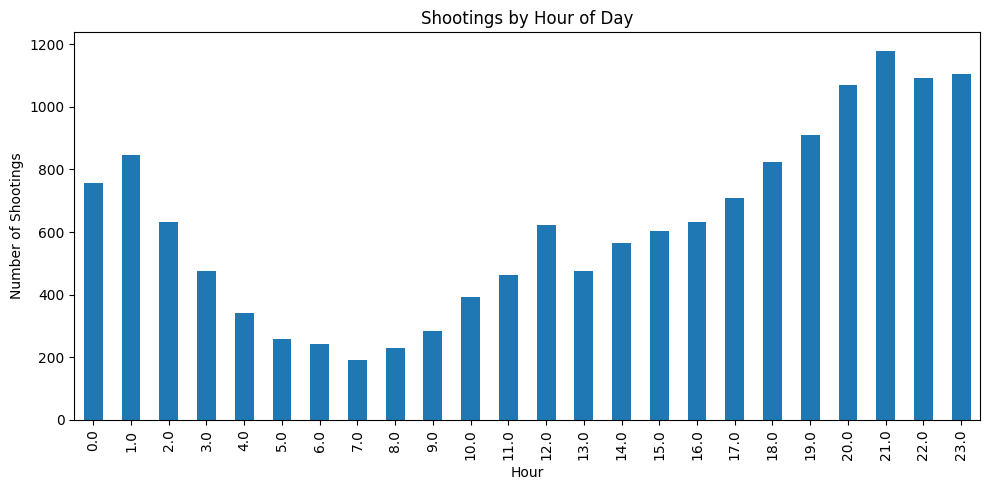

In [27]:
hour_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
hour_counts.plot(kind='bar')
plt.title('Shootings by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Shootings')
plt.tight_layout()
plt.show()

## What This Means: Data Needs Context

#### Looking at this data more closely makes one thing clear: the way we measure data shapes the story we tell.

#### At first glance, totals and rankings make the problem seem straightforward. But once we shift to proportions or examine patterns over time, that simplicity disappears.

#### Shootings aren’t evenly distributed across space or time—they follow patterns. And those patterns only become visible when we move beyond surface-level numbers.

#### Without that context, even accurate data can lead to misleading conclusions.

![](img/conclusion.png)

## Conclusion

This analysis doesn’t answer every question about gun violence in Philadelphia, but it does change how we should interpret the data.

Instead of asking only where shootings happen most, it’s just as important to ask how they are distributed and when they occur.

What initially looks like a simple set of numbers becomes a much more layered story when we shift perspective.

Data doesn’t just reflect reality—it shapes how we understand it.